**Project Title:** Automated Detection of Tomato Leaf Diseases Using Supervised Machine Learning

**Team Members:**


*   Duetes, Greg Danielle C.
*   Faberes, Audrey Zarina R.
*   Mamac, Ira Zaky O.


**Course & Section:**                                                                                                           
BS Data Science 3 - A


In [ ]:
# --- Imports ---
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from skimage.feature import local_binary_pattern
import kagglehub

# --- Scikit-learn Imports ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Model Imports ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
# --- 1. Load Dataset ---
print("Downloading dataset...")
path = kagglehub.dataset_download("nirmalsankalana/crop-pest-and-disease-detection")
print(f"Path to dataset files: {path}")

# Select only the tomato folders
tomato_classes = [
    f for f in os.listdir(path)
    if f.lower().startswith("tomato") and os.path.isdir(os.path.join(path, f))
]
print(f"Found {len(tomato_classes)} tomato classes.")

Using Colab cache for faster access to the 'crop-pest-and-disease-detection' dataset.
Path to dataset files: /kaggle/input/crop-pest-and-disease-detection
Found 5 tomato classes.


Dataset built successfully!
Image count per tomato class:

Tomato verticulium wilt: 773
Tomato healthy: 470
Tomato leaf blight: 1301
Tomato septoria leaf spot: 2743
Tomato leaf curl: 518


/tmp/ipython-input-550992114.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


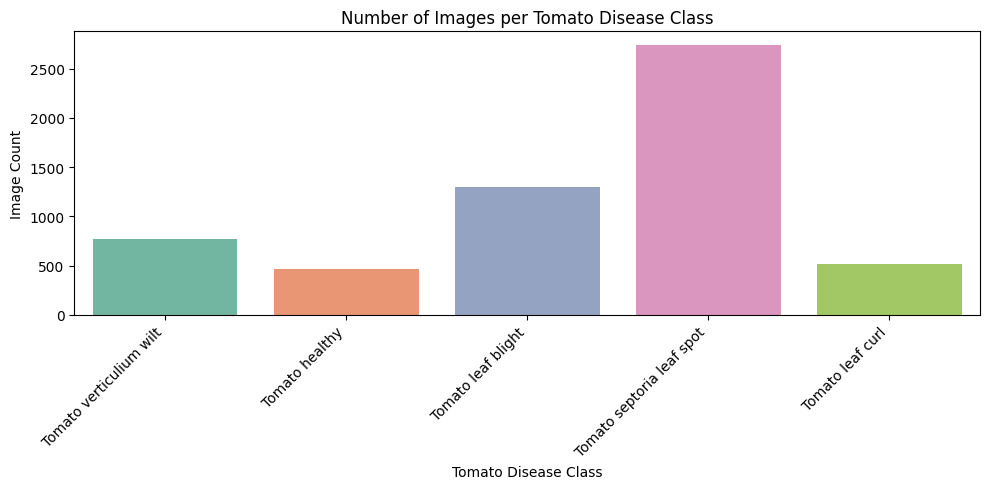

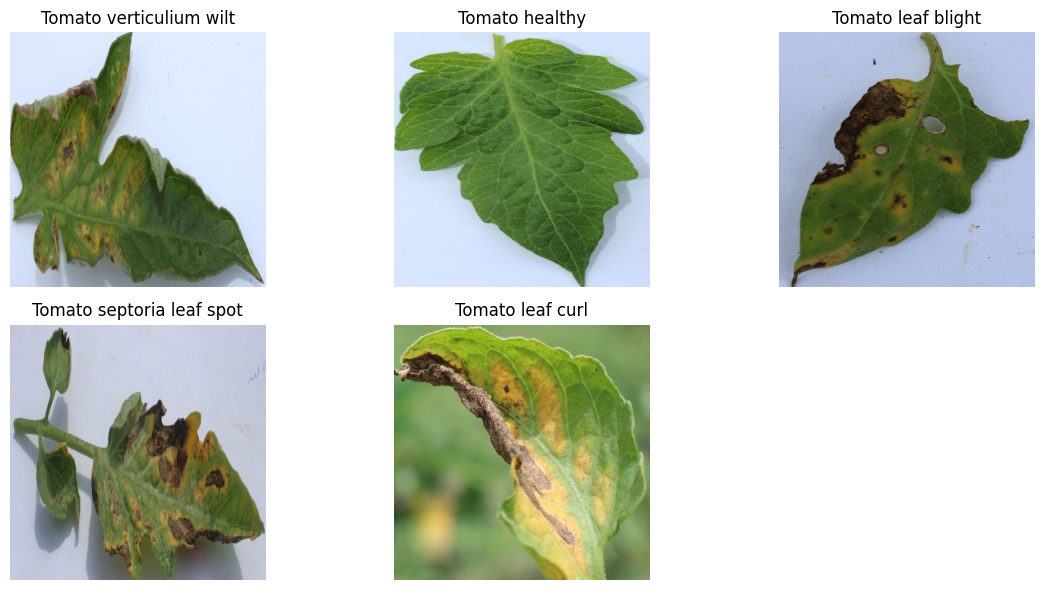

In [ ]:
  # --- 2. Build DataFrame ---
  image_paths, labels = [], []
  for c in tomato_classes:
      class_path = os.path.join(path, c)
      for img_file in os.listdir(class_path):
          if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
              image_paths.append(os.path.join(class_path, img_file))
              labels.append(c)

  df = pd.DataFrame({'image_path': image_paths, 'label': labels})
  print("Dataset built successfully!")

  # Count images per tomato class
  tomato_counts = {}

  for c in tomato_classes:
      class_path = os.path.join(path, c)
      tomato_counts[c] = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

  # Print and visualize
  print("Image count per tomato class:\n")
  for k, v in tomato_counts.items():
      print(f"{k}: {v}")

  plt.figure(figsize=(10,5))
  sns.countplot(x='label', data=df, palette='Set2')
  plt.title('Number of Images per Tomato Disease Class')
  plt.xticks(rotation=45, ha='right')
  plt.xlabel('Tomato Disease Class')
  plt.ylabel('Image Count')
  plt.tight_layout()
  plt.show()

  # Showing Preview Images
  plt.figure(figsize=(12, 6))
  for i, label in enumerate(df['label'].unique()[:6]):
      sample = df[df['label'] == label].sample(1).iloc[0]
      img = cv2.imread(sample['image_path'])
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      plt.subplot(2, 3, i + 1)
      plt.imshow(img)
      plt.title(label)
      plt.axis("off")
  plt.tight_layout()
  plt.show()

In [ ]:
# --- 3. Clean and Balance Dataset ---
df = df.dropna().drop_duplicates().reset_index(drop=True)
df['image_path'] = df['image_path'].astype(str)
df['label'] = df['label'].astype(str)

# Balance the dataset
target_size = 470
balanced_df = (
    df.groupby('label', group_keys=False)
      .sample(n=target_size, random_state=42, replace=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)
print("\nDataset balanced. Class counts:")
print(balanced_df['label'].value_counts())


Dataset balanced. Class counts:
label
Tomato leaf curl             470
Tomato leaf blight           470
Tomato verticulium wilt      470
Tomato healthy               470
Tomato septoria leaf spot    470
Name: count, dtype: int64


In [ ]:
# --- 4. Feature Extraction (LBP + Color) ---
def extract_features_with_lbp(image_path, bins=(8, 8, 8)):
    """Extract combined color histogram and LBP texture features."""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return np.zeros(bins[0]*bins[1]*bins[2] + 256)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hist = cv2.calcHist([img_rgb], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
        cv2.normalize(hist, hist)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
        lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-7)

        return np.concatenate([hist.flatten(), lbp_hist])
    except:
        return np.zeros(bins[0]*bins[1]*bins[2] + 256)

print("\nExtracting features...")
X = np.array([extract_features_with_lbp(p) for p in tqdm(balanced_df['image_path'])])
encoder = LabelEncoder()
y = encoder.fit_transform(balanced_df['label'])

print("\nFeature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Extracting features...


100%|██████████| 2350/2350 [01:47<00:00, 21.79it/s]


Feature matrix shape: (2350, 768)
Labels shape: (2350,)


In [ ]:
# --- 5. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# --- 6. Model Training with GridSearchCV ---

# Define the models to be tuned
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# Define the parameter grids for tuning
param_grids = {
    "Random Forest": {
        'pca__n_components': [128, 256],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20]
    },
    "SVM (RBF)": {
        'pca__n_components': [128, 256],
        'classifier__C': [1, 10],
        'classifier__gamma': ['scale']
    },
    "XGBoost": {
        'pca__n_components': [128, 256],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.1, 0.05]
    },
    "LightGBM": {
        'pca__n_components': [128, 256],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.1, 0.05]
    }
}

results = {}
best_estimators = {}

for name, model in models.items():
    print(f"\n--- Tuning {name} ---")

    # Create the full pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA()),
        ('classifier', model)
    ])

    # Use GridSearchCV to find the best parameters
    grid_search = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    # Save the best model and its score
    best_estimators[name] = grid_search.best_estimator_
    results[name] = grid_search.best_score_

    print(f"Best parameters for {name}:")
    print(grid_search.best_params_)
    print(f"Best cross-val accuracy: {grid_search.best_score_:.4f}")


--- Tuning Random Forest ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Random Forest:
{'classifier__max_depth': 20, 'classifier__n_estimators': 200, 'pca__n_components': 128}
Best cross-val accuracy: 0.7117

--- Tuning SVM (RBF) ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters for SVM (RBF):
{'classifier__C': 10, 'classifier__gamma': 'scale', 'pca__n_components': 256}
Best cross-val accuracy: 0.6798

--- Tuning XGBoost ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:14:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost:
{'classifier__learning_rate': 0.1, 'classifier__n_estimators': 200, 'pca__n_components': 128}
Best cross-val accuracy: 0.7027

--- Tuning LightGBM ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007033 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32639
[LightGBM] [Info] Number of data points in the train set: 1880, number of used features: 128
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi


--- Final Model Evaluation ---

Random Forest Test Set Accuracy: 0.7468
Classification Report:
                           precision    recall  f1-score   support

           Tomato healthy       0.91      0.91      0.91        94
       Tomato leaf blight       0.74      0.65      0.69        94
         Tomato leaf curl       0.75      0.82      0.78        94
Tomato septoria leaf spot       0.57      0.57      0.57        94
  Tomato verticulium wilt       0.76      0.78      0.77        94

                 accuracy                           0.75       470
                macro avg       0.75      0.75      0.75       470
             weighted avg       0.75      0.75      0.75       470


SVM (RBF) Test Set Accuracy: 0.7021
Classification Report:
                           precision    recall  f1-score   support

           Tomato healthy       0.80      0.95      0.87        94
       Tomato leaf blight       0.69      0.54      0.61        94
         Tomato leaf curl       0.73

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1190003689.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_results.keys()), y=list(test_results.values()), palette='viridis')


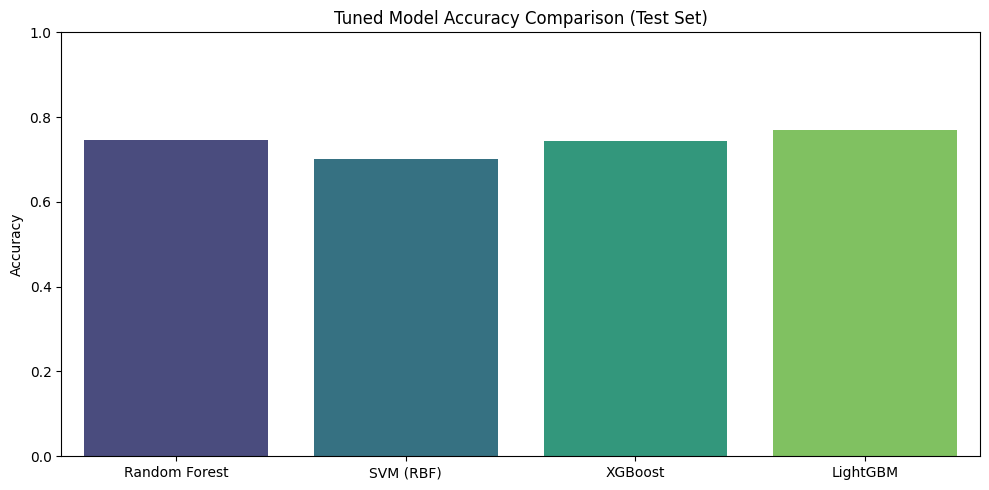


Generating Confusion Matrix for LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


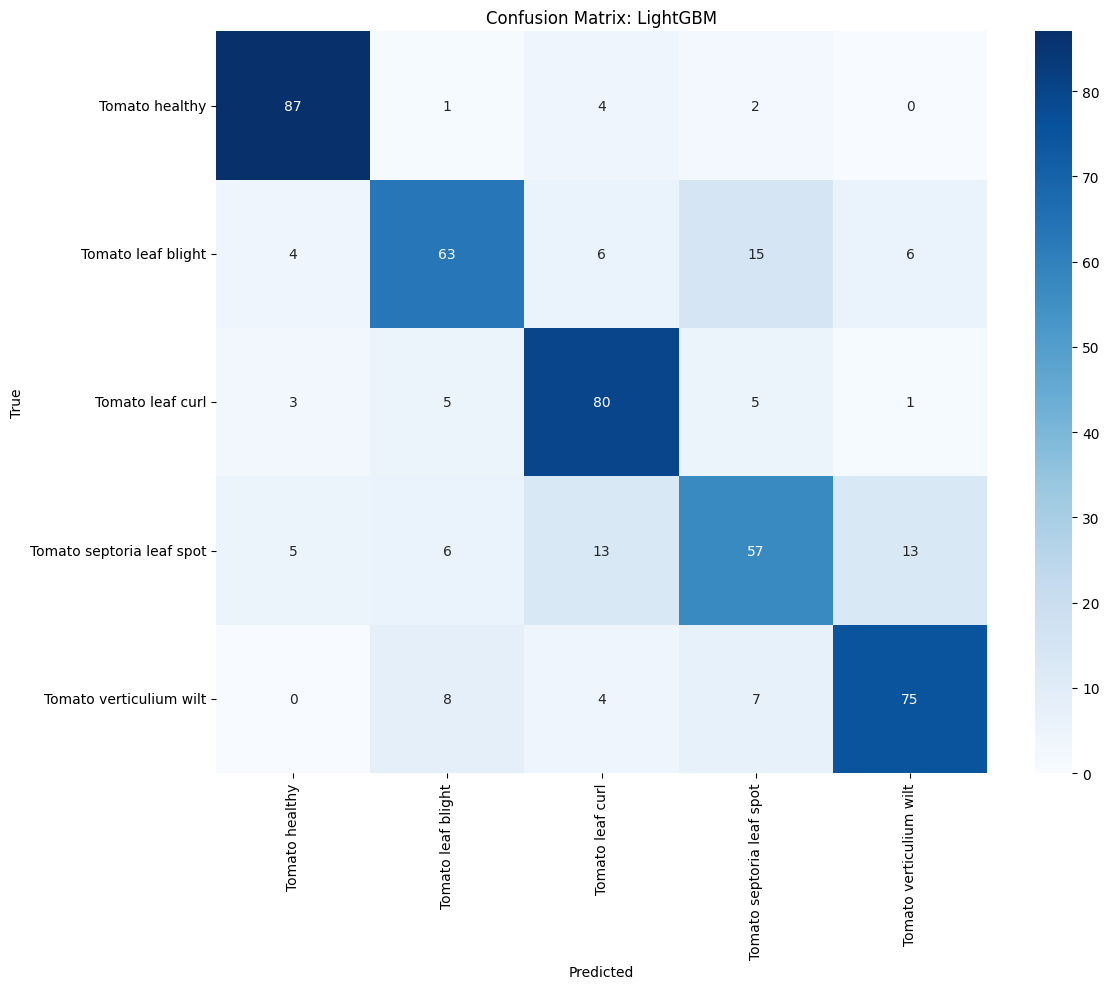


Evaluation complete!


In [ ]:
# --- 7. FINAL EVALUATION & VISUALIZATION ---

print("\n--- Final Model Evaluation ---")

# Evaluate all tuned models on the *test set*
test_results = {}
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_results[name] = acc
    print(f"\n{name} Test Set Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=encoder.classes_))

best_model_name = max(test_results, key=test_results.get)
best_model = best_estimators[best_model_name]
print(f"\nBest Overall Model on Test Set: {best_model_name} ({test_results[best_model_name]:.4f} accuracy)")

# --- Accuracy Bar Plot ---
plt.figure(figsize=(10, 5))
sns.barplot(x=list(test_results.keys()), y=list(test_results.values()), palette='viridis')
plt.title("Tuned Model Accuracy Comparison (Test Set)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# --- Confusion Matrix of Best Model ---
print(f"\nGenerating Confusion Matrix for {best_model_name}...")
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print("\nEvaluation complete!")